# 04 — Analysis (reads the combined result files)
Deep-dive on ONE run: executive scorecard, cohort, claims, validation, N-regime comparison, telematics tiers, EV split, seed spread, verdicts. Every table/figure loops the PREM_ columns present in the file — no hardcoded regime trio.

Input: `shared/results/<scenario>_s<seed>.pkl` written by `run_scenarios.py` (`manifest.json` lists every run).

In [3]:
import os, sys
ROOT = os.path.abspath('')
if ROOT not in sys.path: sys.path.insert(0, ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from voltvision import (
    compare_all,
    ensure_core_methods,
    io,
    load_template,
    lr,
    lr_by,
    quote,
    reg_color,
    reg_label,
    resolve_cards,
    retained_lr,
    rho,
    summary,
)

%matplotlib inline

# --- Which run to dissect (manifest.json lists every scenario x seed) ---
SC, SEED_RUN = 'base', 42
combined = io.load_result(SC, SEED_RUN)
raw = io.sim_book(combined)             # sim book: attributes + claims
books = io.books_from_result(combined)  # {regime: book with FINAL_PREMIUM_SST}
REGIMES_RUN = io.premium_columns(combined)
print(f'{SC}_s{SEED_RUN}: {len(raw)} rows, regimes = {REGIMES_RUN}')

base_s42: 84110 rows, regimes = ['tariff', 'glm', 'telem']


## §1 Executive summary — one scorecard row per regime (N rows, N bars)

,Regime,LR (%),Retained LR (15%),Prem-count rho,Avg prem (RM)
0,tariff,72.91,79.69,0.360,1505.0
1,glm,62.59,53.72,0.634,1753.0
2,telem,62.62,54.07,0.634,1752.0


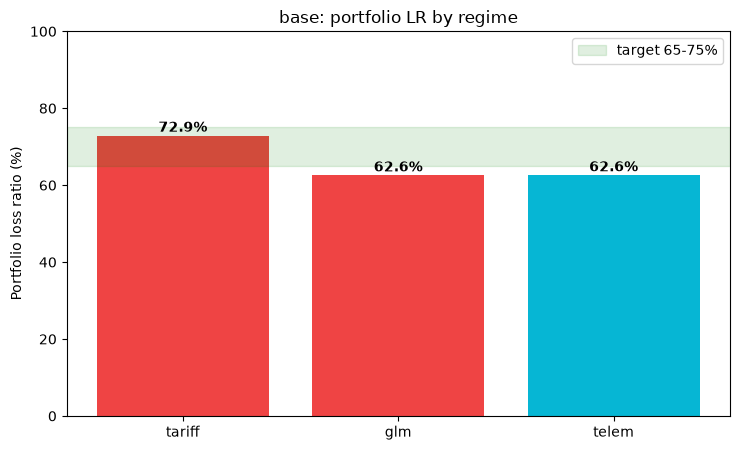

In [4]:
# Scorecard shared with the desk and runner: LR, retained LR, alignment, premium.
tab = compare_all(books)
display(tab)
fig, ax = plt.subplots(figsize=(max(7.5, 2.2 * len(tab)), 4.6))
bars = ax.bar(tab['Regime'], tab['LR (%)'], color=[reg_color(m) for m in REGIMES_RUN])
for b, v in zip(bars, tab['LR (%)']):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.axhspan(65, 75, color='green', alpha=0.12, label='target 65-75%')
ax.set_ylim(0, max(100, tab['LR (%)'].max() + 10))
ax.set_ylabel('Portfolio loss ratio (%)'); ax.set_title(f'{SC}: portfolio LR by regime')
ax.legend(); plt.tight_layout(); plt.show()


## §2 Portfolio & cohort — what the book looks like, how it evolves

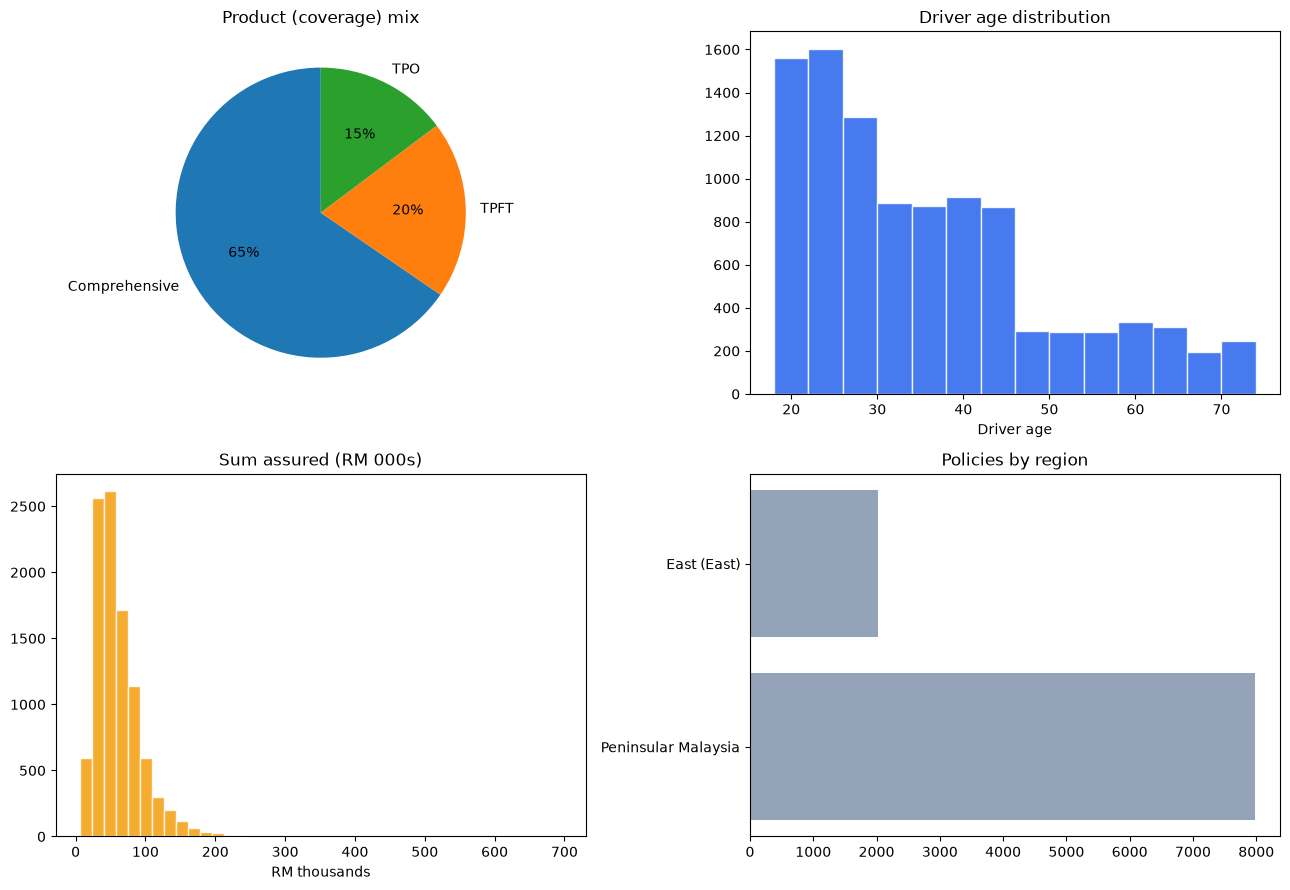

vehicle mix at inception: {'ICE': 0.899, 'EV': 0.101}


Year,Active policies,Claims,Freq,Avg NCD priced,Retention
2026,10000,1791,16.0%,24.6%,87.8%
2027,13776,2523,16.6%,29.9%,88.2%
2028,17152,3014,15.8%,31.9%,88.7%
2029,20212,3533,15.8%,33.6%,88.9%
2030,22970,4090,15.9%,34.7%,89.0%


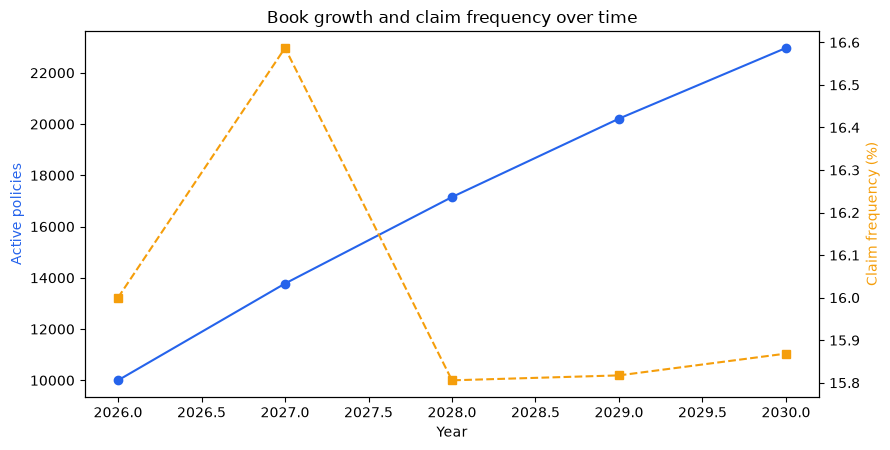

In [5]:
# Inception snapshot (first SIM_YEAR): product mix, driver ages, sums assured, regions.
d0 = raw[raw.SIM_YEAR == raw.SIM_YEAR.min()]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cov_pct = d0['COVERAGE_TYPE'].value_counts(normalize=True) * 100
axes[0, 0].pie(cov_pct.values, labels=cov_pct.index, autopct='%.0f%%', startangle=90)
axes[0, 0].set_title('Product (coverage) mix')
axes[0, 1].hist(d0['DRIVER_AGE'], bins=range(18, 76, 4), color='#2563eb', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Driver age distribution'); axes[0, 1].set_xlabel('Driver age')
axes[1, 0].hist(d0['SUM_ASSURED'] / 1000, bins=40, color='#f59e0b', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Sum assured (RM 000s)'); axes[1, 0].set_xlabel('RM thousands')
reg = d0['REGION'].str.replace(' Malaysia (Sabah, Sawarak & Labuan)', ' (East)', regex=False).value_counts()
axes[1, 1].barh(reg.index, reg.values, color='#94a3b8')
axes[1, 1].set_title('Policies by region')
plt.tight_layout(); plt.show()
print('vehicle mix at inception:', d0['VEHICLE_TYPE'].value_counts(normalize=True).round(3).to_dict())

# Cohort evolution: growth, frequency, priced NCD, retention per year.
rows = []
for y in sorted(raw.SIM_YEAR.unique()):
    yd = raw[raw.SIM_YEAR == y]
    rows.append({'Year': y, 'Active policies': len(yd), 'Claims': int(yd['CLAIM_COUNT'].sum()),
                 'Freq': yd['CLAIM_OCCURRED'].mean(), 'Avg NCD priced': yd['NCD_LEVEL_PRICED'].mean(),
                 'Retention': yd['RENEWED'].mean()})
cs = pd.DataFrame(rows)
display(cs.style.format({'Freq': '{:.1%}', 'Avg NCD priced': '{:.1%}', 'Retention': '{:.1%}'}).hide(axis='index'))
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(cs.Year, cs['Active policies'], '-o', color='#2563eb', label='Active policies')
ax1.set_xlabel('Year'); ax1.set_ylabel('Active policies', color='#2563eb')
ax2 = ax1.twinx()
ax2.plot(cs.Year, cs['Freq'] * 100, '--s', color='#f59e0b', label='Claim frequency %')
ax2.set_ylabel('Claim frequency (%)', color='#f59e0b')
ax1.set_title('Book growth and claim frequency over time')
plt.tight_layout(); plt.show()


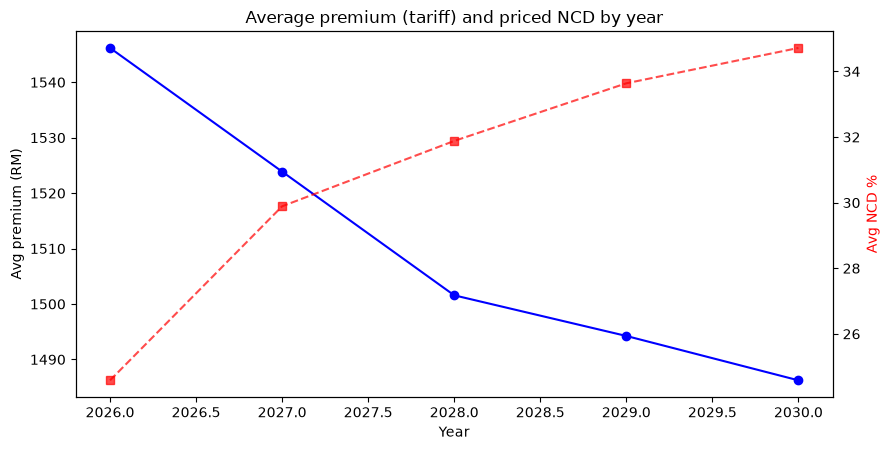

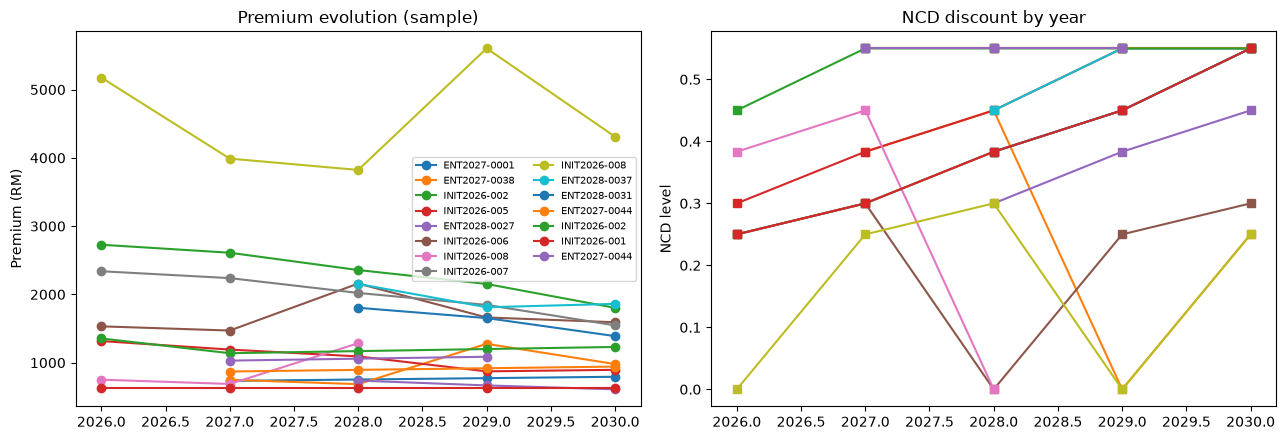

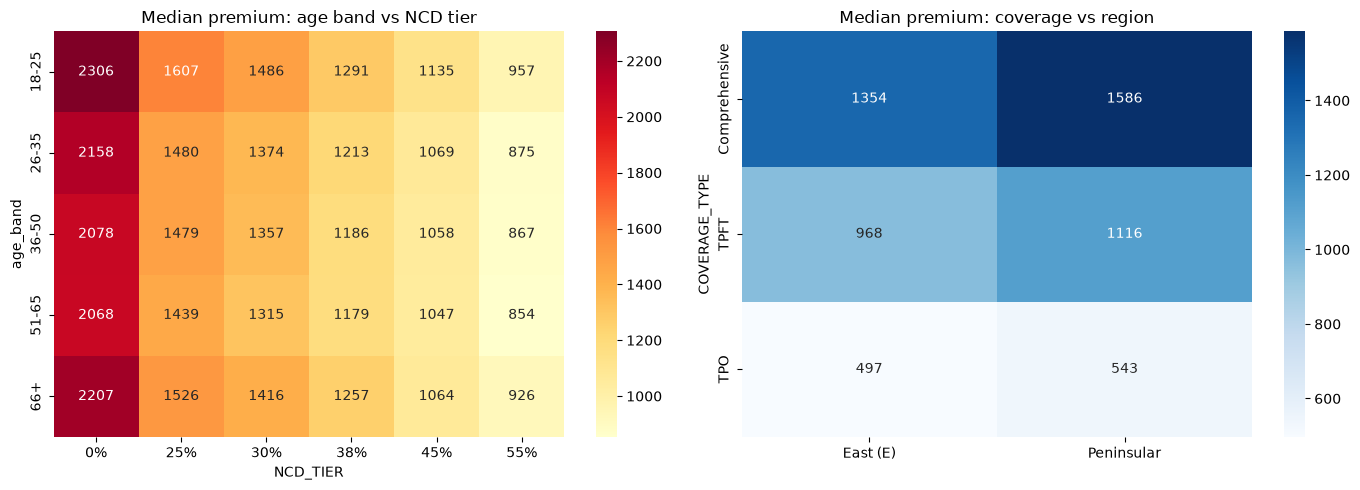

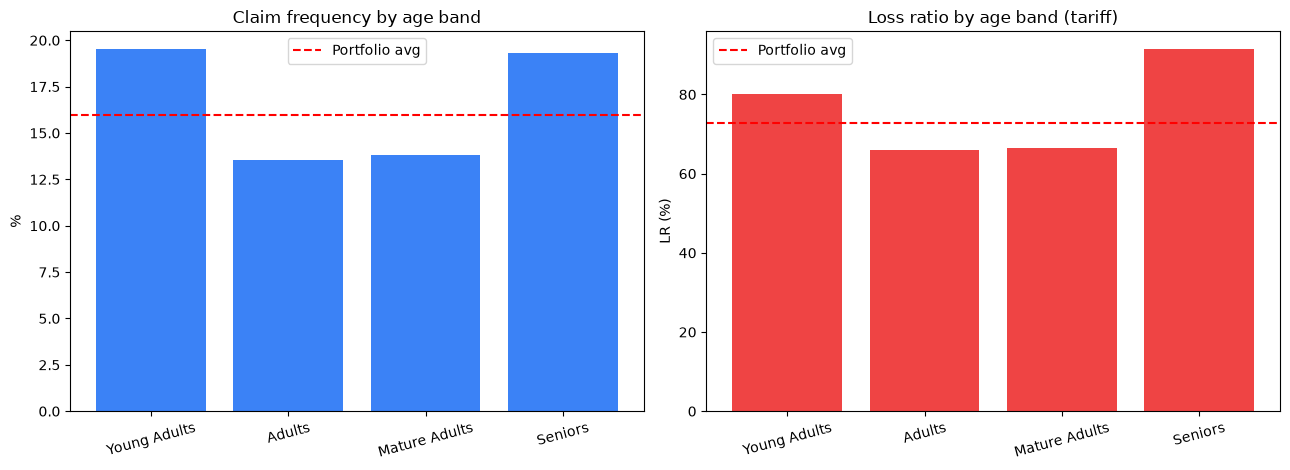

In [6]:
# Premium pressure vs loyalty: tariff avg premium (twin axis: priced NCD).
# First regime's book stands in — claims are identical across regimes.
ref = books[REGIMES_RUN[0]]
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(sorted(ref.SIM_YEAR.unique()),
         ref.groupby('SIM_YEAR')['FINAL_PREMIUM_SST'].mean().values, 'b-o', label='Avg premium')
ax1.set_xlabel('Year'); ax1.set_ylabel('Avg premium (RM)')
ax2 = ax1.twinx()
ax2.plot(sorted(raw.SIM_YEAR.unique()),
         raw.groupby('SIM_YEAR')['NCD_LEVEL_PRICED'].mean().values * 100, 'r--s', alpha=0.7, label='Avg NCD %')
ax2.set_ylabel('Avg NCD %', color='red')
ax1.set_title(f'Average premium ({reg_label(REGIMES_RUN[0])}) and priced NCD by year')
plt.tight_layout(); plt.show()

# Sample policy trails: 15 policies with 3+ years, premium + NCD paths.
ny = raw.groupby('POLID')['SIM_YEAR'].nunique()
picks = list(np.random.RandomState(42).choice(ny[ny >= 3].index, size=15, replace=False))
sel = ref[ref.POLID.isin(picks)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for pid in picks:
    p = sel[sel.POLID == pid].sort_values('SIM_YEAR')
    axes[0].plot(p.SIM_YEAR, p.FINAL_PREMIUM_SST, marker='o', label=str(pid)[:12])
    axes[1].plot(p.SIM_YEAR, p.NCD_LEVEL, marker='s')
axes[0].set_title('Premium evolution (sample)'); axes[0].set_ylabel('Premium (RM)')
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('NCD discount by year'); axes[1].set_ylabel('NCD level')
plt.tight_layout(); plt.show()

# Median premium surfaces: age band x NCD tier, coverage x region.
fd = ref.copy()
fd['NCD_TIER'] = fd.NCD_LEVEL.map({0.0: '0%', 0.25: '25%', 0.30: '30%', 0.3833: '38%', 0.45: '45%', 0.55: '55%'})
fd['age_band'] = pd.cut(fd.DRIVER_AGE, bins=[17, 25, 35, 50, 65, 100],
                        labels=['18-25', '26-35', '36-50', '51-65', '66+'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(fd.groupby(['age_band', 'NCD_TIER'], observed=True)['FINAL_PREMIUM_SST'].median().unstack(),
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Median premium: age band vs NCD tier')
p2 = fd.groupby(['COVERAGE_TYPE', 'REGION'], observed=True)['FINAL_PREMIUM_SST'].median().unstack()
p2.columns = [c.replace(' Malaysia (Sabah, Sawarak & Labuan)', ' (E)').replace(' Malaysia', '') for c in p2.columns]
sns.heatmap(p2, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Median premium: coverage vs region')
plt.tight_layout(); plt.show()

# U-shaped age risk: frequency + LR per driver band vs portfolio average.
cats = ['Young Adults', 'Adults', 'Mature Adults', 'Seniors']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
freq_age = ref.groupby('DRIVER_AGE_CAT', observed=True)['CLAIM_OCCURRED'].mean().reindex(cats) * 100
axes[0].bar(freq_age.index, freq_age.values, color='#3b82f6')
axes[0].axhline(ref['CLAIM_OCCURRED'].mean() * 100, ls='--', color='red', label='Portfolio avg')
axes[0].set_title('Claim frequency by age band'); axes[0].set_ylabel('%')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=15)
lr_age = pd.Series({c: lr(ref[ref.DRIVER_AGE_CAT == c]) for c in cats})
axes[1].bar(lr_age.index, lr_age.values, color='#ef4444')
axes[1].axhline(lr(ref), ls='--', color='red', label='Portfolio avg')
axes[1].set_title(f'Loss ratio by age band ({reg_label(REGIMES_RUN[0])})'); axes[1].set_ylabel('LR (%)')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


## §3 Claims profile — frequency, severity, peril mix, LR by coverage (regime-independent counts, LR per first regime)

Coverage,Policies,Freq,Claims,Sev/claim (RM),LR (%)
Comprehensive,54023,19.1%,11607,"5,138",61.400000
TPFT,17108,11.9%,2171,"9,841",98.200000
TPO,12979,8.6%,1173,"9,604",146.900000


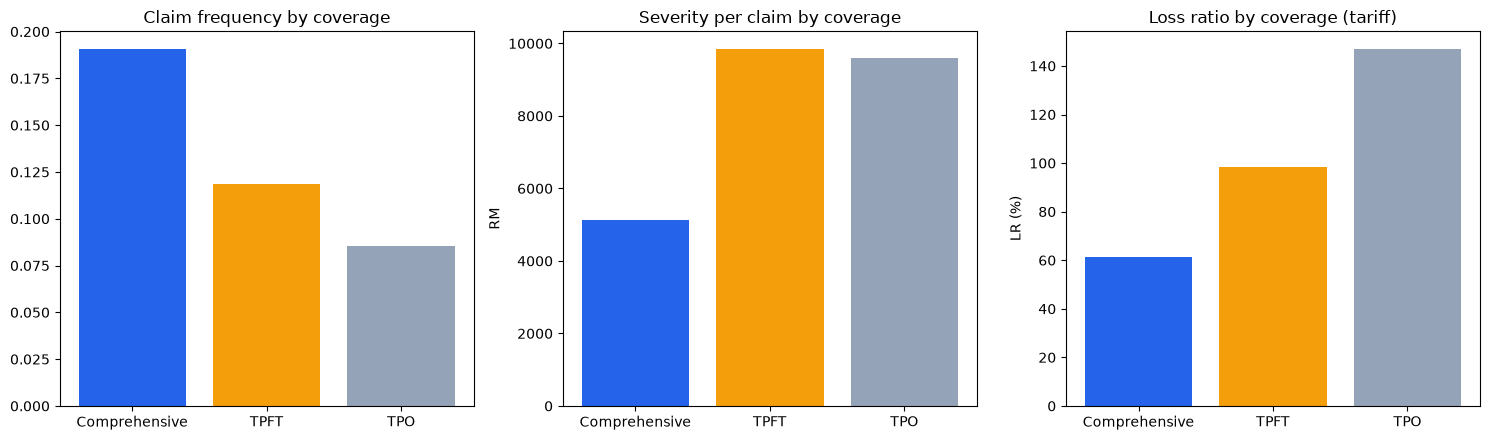

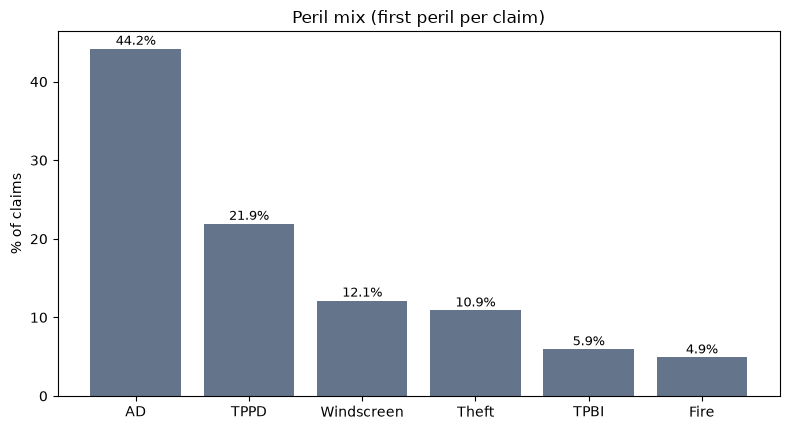

mean severity per first peril (RM):
pf
TPBI          23907.0
Theft         14108.0
Fire           9527.0
TPPD           5427.0
AD             4526.0
Windscreen     2068.0


In [7]:
# Claims don't depend on pricing — one table from raw, LR from the first regime.
rows = []
for cov in ('Comprehensive', 'TPFT', 'TPO'):
    sub = raw[raw.COVERAGE_TYPE == cov]
    n = sub['CLAIM_COUNT'].sum()
    rows.append({'Coverage': cov, 'Policies': len(sub), 'Freq': sub['CLAIM_OCCURRED'].mean(),
                 'Claims': int(n), 'Sev/claim (RM)': round(sub['CLAIM_AMOUNT'].sum() / n, 0) if n else 0,
                 'LR (%)': round(lr(books[REGIMES_RUN[0]][books[REGIMES_RUN[0]].COVERAGE_TYPE == cov]), 1)})
cdf = pd.DataFrame(rows)
display(cdf.style.format({'Freq': '{:.1%}', 'Sev/claim (RM)': '{:,.0f}'}).hide(axis='index'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].bar(cdf['Coverage'], cdf['Freq'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[0].set_title('Claim frequency by coverage')
axes[1].bar(cdf['Coverage'], cdf['Sev/claim (RM)'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[1].set_title('Severity per claim by coverage'); axes[1].set_ylabel('RM')
axes[2].bar(cdf['Coverage'], cdf['LR (%)'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[2].set_title(f"Loss ratio by coverage ({reg_label(REGIMES_RUN[0])})"); axes[2].set_ylabel('LR (%)')
plt.tight_layout(); plt.show()

# Peril mix: first peril per policy-year tells the story (multi-claim joins split on '/').
peril_first = raw[raw.CLAIM_AMOUNT > 0]['CLAIM_PERIL'].str.split('/').str[0]
mix = peril_first.value_counts(normalize=True).sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(mix.index, mix.values, color='#64748b')
ax.set_title('Peril mix (first peril per claim)'); ax.set_ylabel('% of claims')
for x, v in zip(mix.index, mix.values):
    ax.text(x, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
sev_peril = raw[raw.CLAIM_AMOUNT > 0].assign(pf=peril_first).groupby('pf')['CLAIM_AMOUNT'].mean().sort_values(ascending=False)
print('mean severity per first peril (RM):')
print(sev_peril.round(0).to_string())


## §4 Validation — PASS/FAIL sanity checks + distribution tests (model trust)

In [8]:
# Cheap invariants first: any FAIL here stops trust in everything downstream.
res, checks = raw, []
add = lambda name, ok, detail='': checks.append({'Check': name, 'Pass': 'PASS' if ok else 'FAIL', 'Detail': detail})
add('Claim frequency within 10-20%', 0.10 <= res['CLAIM_OCCURRED'].mean() <= 0.20, f"{res['CLAIM_OCCURRED'].mean():.1%}")
add('TPO claim freq < Comprehensive',
    res.loc[res.COVERAGE_TYPE == 'TPO', 'CLAIM_OCCURRED'].mean() < res.loc[res.COVERAGE_TYPE == 'Comprehensive', 'CLAIM_OCCURRED'].mean())
add('Claims reset NCD to 0', (res.loc[res.CLAIM_OCCURRED, 'NCD_YEARS'] == 0).mean() >= 0.99)
add('Claim-free years increment NCD', (res.loc[~res.CLAIM_OCCURRED, 'NCD_YEARS'] >= 1).mean() >= 0.99)
add('No nulls in key fields', res[['CLAIM_COUNT', 'CLAIM_AMOUNT', 'CLAIM_LAMBDA', 'NCD_LEVEL', 'RENEWED']].isnull().sum().sum() == 0)
add('Mean driver age rises across years',
    res.groupby('SIM_YEAR')['DRIVER_AGE'].mean().iloc[-1] > res.groupby('SIM_YEAR')['DRIVER_AGE'].mean().iloc[0])
ev = res[res.CLAIM_PERIL.str.split('/').str[0].isin(['AD', 'Theft', 'Fire'])]
add('EV severity > ICE on own-damage perils',
    ev.loc[ev.VEHICLE_TYPE == 'EV', 'CLAIM_AMOUNT'].mean() > ev.loc[ev.VEHICLE_TYPE == 'ICE', 'CLAIM_AMOUNT'].mean())
t = pd.DataFrame(checks)
display(t)
print(f"core checks: {(t.Pass == 'PASS').sum()}/{len(t)} passed")
print('retention claimed vs clean:', res.groupby('CLAIM_OCCURRED')['RENEWED'].mean().round(3).to_dict())

# Distribution shape: log-premium ~ normal (mixture accepted), counts ~ Poisson,
# severity ~ gamma per coverage. KS < 0.20 passes (mixtures never fit perfectly).
from scipy.stats import kstest, norm, gamma as gamma_dist
prem = books[REGIMES_RUN[0]]['FINAL_PREMIUM_SST']
lp = np.log(prem)
ks_lp, _ = kstest(lp, norm(loc=lp.mean(), scale=lp.std()).cdf)
print(f'log-premium KS={ks_lp:.3f} (pass < 0.20) | skew={lp.skew():.3f}')
vm = res.CLAIM_COUNT.var() / res.CLAIM_COUNT.mean()
print(f'claim count var/mean={vm:.3f} (Poisson ~= 1; heterogeneity inflates)')
for cov in ['Comprehensive', 'TPFT', 'TPO']:
    s = res[(res.COVERAGE_TYPE == cov) & (res.CLAIM_AMOUNT > 0)].CLAIM_AMOUNT
    if len(s) > 30:
        sh, lo, sc = gamma_dist.fit(s, floc=0)
        ks, _ = kstest(s, gamma_dist(a=sh, loc=lo, scale=sc).cdf)
        print(f'{cov}: gamma shape={sh:.2f} KS={ks:.3f} mean=RM{s.mean():,.0f}')


,Check,Pass,Detail
0,Claim frequency within 10-20%,PASS,16.0%
1,TPO claim freq < Comprehensive,PASS,
2,Claims reset NCD to 0,PASS,
3,Claim-free years increment NCD,PASS,
4,No nulls in key fields,PASS,
5,Mean driver age rises across years,PASS,
6,EV severity > ICE on own-damage perils,PASS,


core checks: 7/7 passed
retention claimed vs clean: {False: 0.929, True: 0.661}
log-premium KS=0.015 (pass < 0.20) | skew=0.020
claim count var/mean=1.040 (Poisson ~= 1; heterogeneity inflates)
Comprehensive: gamma shape=0.56 KS=0.056 mean=RM5,791
TPFT: gamma shape=0.54 KS=0.040 mean=RM10,519
TPO: gamma shape=0.41 KS=0.070 mean=RM10,149


## §5 Pricing comparison — N regimes, one scorecard, effectiveness checks

,Regime,LR (%),Retained LR (15%),Prem-count rho,Avg prem (RM)
0,tariff,72.91,79.69,0.360,1505.0
1,glm,62.59,53.72,0.634,1753.0
2,telem,62.62,54.07,0.634,1752.0


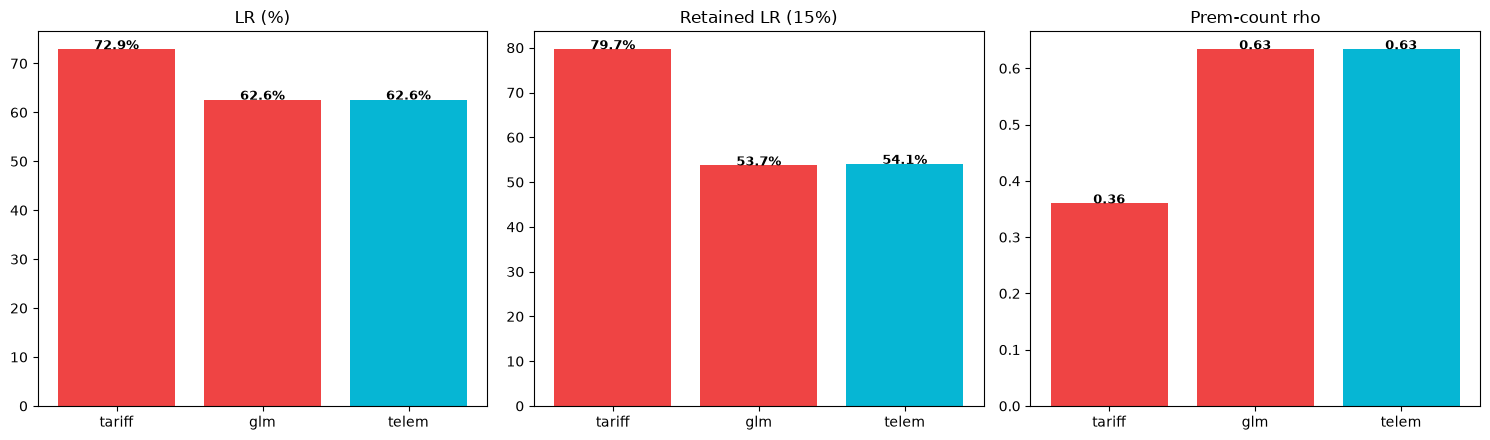

In [9]:
# Same scorecard as §1, plus one panel per metric — bars scale to N regimes.
pcd = compare_all(books)
display(pcd)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, fmt in zip(axes, ['LR (%)', f"Retained LR ({0.15:.0%})", 'Prem-count rho'], ['{:.1f}%', '{:.1f}%', '{:.2f}']):
    bars = ax.bar(pcd['Regime'], pcd[col], color=[reg_color(m) for m in REGIMES_RUN])
    for b, v in zip(bars, pcd[col]):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v), ha='center', fontweight='bold', fontsize=9)
    ax.set_title(col)
plt.tight_layout(); plt.show()


In [10]:
# Effectiveness checks (N-safe): risk signals separate claimants; the best
# risk-priced regime beats tariff on LR and retained LR; alignment reported.
ck, b0 = [], books[REGIMES_RUN[0]]
c13 = lambda name, ok, detail='': ck.append({'Check': name, 'Pass': 'PASS' if ok else 'FAIL', 'Detail': detail})
c13('Behavior risk higher for claimants',
    b0.loc[b0.CLAIM_OCCURRED, 'BEHAVIOR_RISK'].mean() > b0.loc[~b0.CLAIM_OCCURRED, 'BEHAVIOR_RISK'].mean())
c13('Telematics score lower for claimants',
    b0.loc[b0.CLAIM_OCCURRED, 'telematics_score'].mean() < b0.loc[~b0.CLAIM_OCCURRED, 'telematics_score'].mean())
lrs = {m: lr(b) for m, b in books.items()}
best = min(lrs, key=lrs.get)
c13(f'Best regime ({reg_label(best)}) LR < {reg_label(REGIMES_RUN[0])} LR',
    lrs[best] < lrs[REGIMES_RUN[0]], f"{lrs[best]:.1f}% vs {lrs[REGIMES_RUN[0]]:.1f}%")
rls = {m: retained_lr(b) for m, b in books.items()}
c13('Best retained LR < first-regime retained LR', min(rls.values()) < rls[REGIMES_RUN[0]])
rhos = {m: rho(b) for m, b in books.items()}
c13(f"Strongest alignment: {reg_label(max(rhos, key=rhos.get))} rho={max(rhos.values()):.3f}", True)
t = pd.DataFrame(ck)
display(t)
print(f'effectiveness: {(t.Pass == "PASS").sum()}/{len(t)} passed')


,Check,Pass,Detail
0,Behavior risk higher for claimants,PASS,
1,Telematics score lower for claimants,PASS,
2,Best regime (glm) LR < tariff LR,PASS,62.6% vs 72.9%
3,Best retained LR < first-regime retained LR,PASS,
4,Strongest alignment: telem rho=0.634,PASS,


effectiveness: 5/5 passed


## §5b Cross-scenario comparison — the review table
Same regimes across books: tariff on ICE-only, combined, EV-only; the ML
regimes on EV-only. Rows: TPO loss ratio, average loss ratio, premium
lower/upper bound (min-max across policy-years), average premium.
Missing columns mean the scenario hasn't been simulated yet — run
`python run_scenarios.py` first.

In [11]:
# Build the review table from results on disk (same seed as this analysis).
pairs = [('ICE', 'tariff', 'Tariff ICE ONLY'),
         ('MIX', 'tariff', 'Tariff EV and ICE combined'),
         ('EV', 'tariff', 'Tariff EV ONLY'),
         ('EV', 'glm', 'GLM EV ONLY'),
         ('EV', 'telem', 'GLM + Telematics EV ONLY')]
rows, missing = {}, []
for sc, regime, label in pairs:
    try:
        b = io.books_from_result(io.load_result(sc, SEED_RUN))[regime]
    except FileNotFoundError:
        missing.append(f'{sc}/{regime}')
        continue
    rows[label] = {
        'TPO Loss Ratio (%)': round(lr(b[b.COVERAGE_TYPE == 'TPO']), 1),
        'Average Loss Ratio (%)': round(lr(b), 1),
        'Premium lower-upper bound (RM)':
            f"{b.FINAL_PREMIUM_SST.min():,.0f} - {b.FINAL_PREMIUM_SST.max():,.0f}",
        'Average premium (RM)': round(b.FINAL_PREMIUM_SST.mean(), 0)}
if missing:
    print('not produced by the current scenario set (add ICE/MIX/EV runs, or edit pairs):', missing)
display(pd.DataFrame(rows).T)

not produced by the current scenario set (add ICE/MIX/EV runs, or edit pairs): ['ICE/tariff', 'MIX/tariff', 'EV/tariff', 'EV/glm', 'EV/telem']


""


## §5c Leak check — in-sample vs out-of-sample training
Default pricing now trains on a separate historical book (seed 42,
2021–2025); the priced book spans 2026–2030. The legacy path
(`train_book_seed=None`) trains on the priced book itself. The gap shows
how optimistic the old self-trained numbers were.

In [12]:
# Same book, same claims: only the training source differs.
ensure_core_methods()  # load 02x CALC cells for live quoting
cfg = load_template()
cards_out = resolve_cards(cfg)   # default: separate earlier training window
cfg_in = {**cfg, 'pricing': {'glm': {'train_book_seed': None},
                             'telem': {'train_book_seed': None}}}
cards_in = resolve_cards(cfg_in)
rows = []
for m in REGIMES_RUN:
    if m not in cfg['regimes']:
        continue
    b_in = quote(raw, m, cards_in[m], cfg_in, base_cfg=cfg)
    b_out = quote(raw, m, cards_out[m], cfg, base_cfg=cfg)
    rows.append({'Regime': reg_label(m),
                 'In-sample LR (%)': round(lr(b_in), 2),
                 'Out-of-sample LR (%)': round(lr(b_out), 2),
                 'Leak (pp)': round(lr(b_in) - lr(b_out), 2),
                 'In rho': round(rho(b_in), 4), 'Out rho': round(rho(b_out), 4),
                 'Avg prem in/out (RM)': f"{b_in.FINAL_PREMIUM_SST.mean():,.0f} / {b_out.FINAL_PREMIUM_SST.mean():,.0f}"})
display(pd.DataFrame(rows))
print('negative gap = in-sample understates LR (optimism); rho barely moves. Tariff has no training step.')

loader: 02a_tariff.ipynb -> regime 'tariff'
tariff calc registered
loader: 02b_glm.ipynb -> regime 'glm'
glm calc registered
loader: 02c_telem.ipynb -> regime 'telem'
telem calc registered


,Regime,In-sample LR (%),Out-of-sample LR (%),Leak (pp),In rho,Out rho,Avg prem in/out (RM)
0,Tariff,72.91,72.91,0.0,0.3596,0.3596,"1,505 / 1,505"
1,GLM,62.59,62.59,0.0,0.6336,0.6336,"1,753 / 1,753"
2,GLM+Telematics,62.62,62.62,0.0,0.6336,0.6336,"1,752 / 1,752"


negative gap = in-sample understates LR (optimism); rho barely moves. Tariff has no training step.


## §6 Telematics tiers — premium and LR per score band, one column-pair per regime

,Tariff prem,GLM prem,GLM+Telematics prem,Tariff LR,GLM LR,GLM+Telematics LR
Telematics tier,,,,,,
<50 High risk,1446.0,1827.0,2014.0,66.9,52.9,48.0
50-70,1529.0,2003.0,2091.0,82.1,62.7,60.0
70-85,1512.0,1812.0,1814.0,74.6,62.2,62.1
85-100 Safe,1483.0,1551.0,1509.0,66.3,63.4,65.2


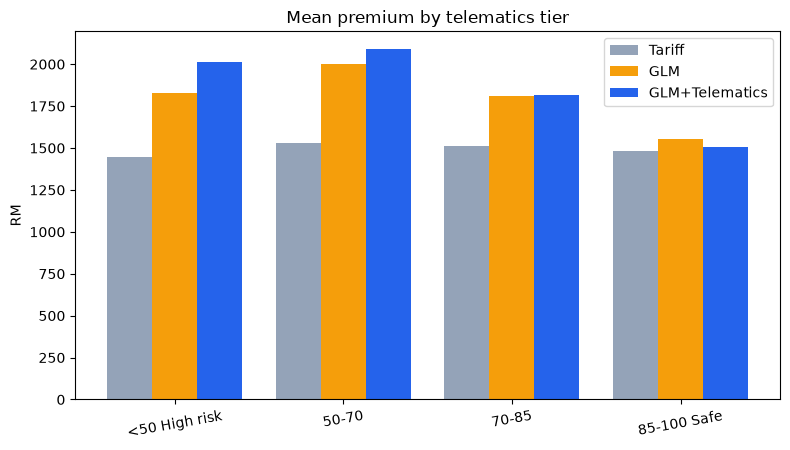

In [13]:
# Score bands from safe (85-100) to high-risk (<50): does dearer telematics
# premium actually sit where the losses are, per regime?
def tier_table(b):
    d = b.copy()
    d['tier'] = pd.cut(d['telematics_score'], bins=[0, 50, 70, 85, 100],
                       labels=['<50 High risk', '50-70', '70-85', '85-100 Safe'])
    g = d.groupby('tier', observed=False).agg(n=('POLID', 'size'), mean_prem=('FINAL_PREMIUM_SST', 'mean'),
                                              claims=('CLAIM_AMOUNT', 'sum'), prem_sum=('FINAL_PREMIUM_SST', 'sum'))
    g['lr'] = g['claims'] / g['prem_sum'] * 100
    return g[['n', 'mean_prem', 'lr']]

tiers = {m: tier_table(b) for m, b in books.items()}
tab = pd.DataFrame({f'{reg_label(m)} prem': tiers[m]['mean_prem'].round(0) for m in REGIMES_RUN})
tab = tab.join(pd.DataFrame({f'{reg_label(m)} LR': tiers[m]['lr'].round(1) for m in REGIMES_RUN}))
tab.index.name = 'Telematics tier'
display(tab)
x = np.arange(len(tab))
fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(REGIMES_RUN)), 4.6))
w = 0.8 / len(REGIMES_RUN)
for i, m in enumerate(REGIMES_RUN):
    ax.bar(x + (i - (len(REGIMES_RUN) - 1) / 2) * w, tiers[m]['mean_prem'], w,
           label=reg_label(m), color=reg_color(m))
ax.set_xticks(x); ax.set_xticklabels(tab.index, rotation=10)
ax.set_title('Mean premium by telematics tier'); ax.set_ylabel('RM'); ax.legend()
plt.tight_layout(); plt.show()


## §7 EV vs ICE — share, frequency, severity, LR per year (first regime prices; counts identical)

,EV share,EV freq,EV sev/claim,EV LR,EV prem,ICE share,ICE freq,ICE sev/claim,ICE LR,ICE prem
SIM_YEAR,,,,,,,,,,
2026,10.1%,17.3%,"8,144",72.2%,"2,164",89.9%,15.9%,"6,130",73.7%,"1,477"
2027,9.9%,16.9%,"7,947",69.5%,"2,131",90.1%,16.5%,"5,947",74.6%,"1,457"
2028,9.9%,17.4%,"8,007",72.5%,"2,158",90.1%,15.6%,"5,671",68.9%,"1,429"
2029,9.8%,17.0%,"8,377",72.2%,"2,151",90.2%,15.7%,"6,112",74.6%,"1,423"
2030,9.7%,15.6%,"7,615",61.5%,"2,138",90.3%,15.9%,"5,981",75.4%,"1,416"


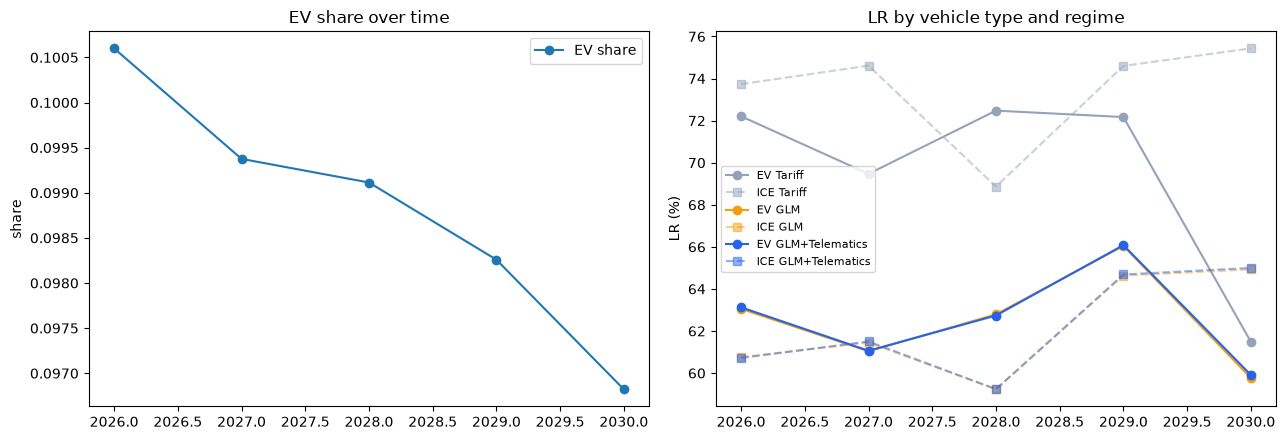

In [14]:
# EV costs more to assure and repair: check the book prices that in.
# Adoption-ramp scenarios need the EV-ramp engine TODO — out of scope here.
def evice(g):
    out = {}
    for nm in ('EV', 'ICE'):
        s = g[g.VEHICLE_TYPE == nm]
        n = s.CLAIM_COUNT.sum()
        out[nm + ' share'] = len(s) / len(g)
        out[nm + ' freq'] = s.CLAIM_OCCURRED.mean()
        out[nm + ' sev/claim'] = s.CLAIM_AMOUNT.sum() / n if n else float('nan')
        out[nm + ' LR'] = s.CLAIM_AMOUNT.sum() / s.FINAL_PREMIUM_SST.sum() if s.FINAL_PREMIUM_SST.sum() else float('nan')
        out[nm + ' prem'] = s.FINAL_PREMIUM_SST.mean()
    return pd.Series(out)

ev_df = books[REGIMES_RUN[0]].groupby('SIM_YEAR').apply(evice)
display(ev_df.style.format({'EV share': '{:.1%}', 'ICE share': '{:.1%}', 'EV freq': '{:.1%}',
                            'ICE freq': '{:.1%}', 'EV sev/claim': '{:,.0f}', 'ICE sev/claim': '{:,.0f}',
                            'EV LR': '{:.1%}', 'ICE LR': '{:.1%}',
                            'EV prem': '{:,.0f}', 'ICE prem': '{:,.0f}'}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ev_df.index, ev_df['EV share'], '-o', label='EV share')
axes[0].set_title('EV share over time'); axes[0].set_ylabel('share'); axes[0].legend()
for m in REGIMES_RUN:
    e = books[m].groupby('SIM_YEAR').apply(
        lambda g: pd.Series({'EV': g[g.VEHICLE_TYPE == 'EV'].CLAIM_AMOUNT.sum() / g[g.VEHICLE_TYPE == 'EV'].FINAL_PREMIUM_SST.sum(),
                              'ICE': g[g.VEHICLE_TYPE == 'ICE'].CLAIM_AMOUNT.sum() / g[g.VEHICLE_TYPE == 'ICE'].FINAL_PREMIUM_SST.sum()}))
    axes[1].plot(e.index, e['EV'] * 100, '-o', label=f"EV {reg_label(m)}", color=reg_color(m))
    axes[1].plot(e.index, e['ICE'] * 100, '--s', label=f"ICE {reg_label(m)}", color=reg_color(m), alpha=0.5)
axes[1].set_title('LR by vehicle type and regime'); axes[1].set_ylabel('LR (%)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## §8 Seed spread — every seed of every scenario (read from the manifest)
`run_scenarios.py` already ran each scenario once per seed in `seeds.json`; this section aggregates those results. No compute here — re-run the runner to refresh.

mean     p05     p95  P_LR_gt
scenario          regime                                 
base              glm      62.59   62.59   62.59      0.0
                  tariff   72.91   72.91   72.91      0.0
                  telem    62.62   62.62   62.62      0.0
combo_hard        glm      52.87   52.87   52.87      0.0
                  tariff  115.28  115.28  115.28      1.0
                  telem    52.92   52.92   52.92      0.0
ev_only           glm      63.74   63.74   63.74      0.0
                  tariff   70.00   70.00   70.00      0.0
                  telem    63.85   63.85   63.85      0.0
ev_only_tpo_heavy glm      66.04   66.04   66.04      0.0
                  tariff   76.72   76.72   76.72      1.0
                  telem    66.45   66.45   66.45      0.0
mix_60_40         glm      62.75   62.75   62.75      0.0
                  tariff   71.39   71.39   71.39      0.0
                  telem    62.80   62.80   62.80      0.0
tpo_heavy         glm      63.20   63.20   63.20      0.0
                  tariff   84.32   84.32   84.32      1.0
                  telem    63.28   63.28   63.28      0.0

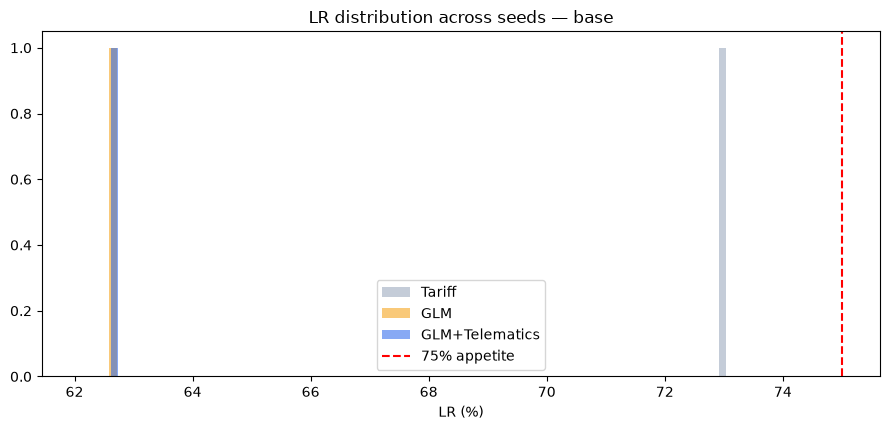

In [15]:
# Seed spread straight from the manifest — no re-simulation here.
# Refresh with `python run_scenarios.py` (one run per scenario x seed in seeds.json).
manifest = io.load_manifest()
rows = [{'scenario': entry['scenario'], 'seed': entry['seed'], 'regime': regime,
         'lr': metrics['lr']}
        for entry in manifest.values()
        for regime, metrics in entry['metrics'].items()]
mc = pd.DataFrame(rows)
appetite = 75
tab = mc.groupby(['scenario', 'regime'])['lr'].agg(
    mean='mean', p05=lambda x: x.quantile(.05), p95=lambda x: x.quantile(.95),
    P_LR_gt=lambda x: (x > appetite).mean())
display(tab.round(2))
here = mc[mc.scenario == SC]
fig, ax = plt.subplots(figsize=(9, 4.4))
for m in REGIMES_RUN:
    sub = here[here.regime == m]
    if len(sub):
        ax.hist(sub['lr'], bins=8, alpha=0.55, label=reg_label(m), color=reg_color(m))
ax.axvline(appetite, color='red', ls='--', label=f'{appetite}% appetite')
ax.legend(); ax.set_xlabel('LR (%)')
ax.set_title(f'LR distribution across seeds — {SC}')
plt.tight_layout(); plt.show()

## §9 Verdicts — numbers first, words second (all values computed above, none hardcoded)

In [16]:
# Each line prints a computed fact: re-run the book, the verdicts follow.
lrs = {m: lr(b) for m, b in books.items()}
best = min(lrs, key=lrs.get)
tpo = {m: books[m][books[m].COVERAGE_TYPE == 'TPO'] for m in REGIMES_RUN}
print(f"1. Portfolio LR ({SC}): " + "; ".join(f"{reg_label(m)} {v:.1f}%" for m, v in lrs.items()))
print(f"2. Best regime is {reg_label(best)} at {lrs[best]:.1f}% (target band 65-75%).")
print(f"3. Tariff TPO LR is {lr(tpo[REGIMES_RUN[0]]):.1f}% — the flat TPO rate underprices; "
      "raise tpo_sa_pct/tpo_loading via a scenario pricing blob (or the 02a card).")
print(f"4. Strongest alignment: {reg_label(max(books, key=lambda m: rho(books[m])))} "+
      f"rho={max(rho(b) for b in books.values()):.3f}.")
print(f"5. Shedding the dearest 15% moves {reg_label(best)} LR to {retained_lr(books[best]):.1f}%.")
print("6. EV adoption scenarios wait on the EV-ramp engine TODO (entrants use base mix today).")


1. Portfolio LR (base): Tariff 72.9%; GLM 62.6%; GLM+Telematics 62.6%
2. Best regime is GLM at 62.6% (target band 65-75%).
3. Tariff TPO LR is 146.9% — the flat TPO rate underprices; raise tpo_sa_pct/tpo_loading via a scenario pricing blob (or the 02a card).
4. Strongest alignment: GLM+Telematics rho=0.634.
5. Shedding the dearest 15% moves GLM LR to 53.7%.
6. EV adoption scenarios wait on the EV-ramp engine TODO (entrants use base mix today).
